# 🧪 Experimental Notebook: Imbalanced Fraud Detection

**Objectif:** Comparer plusieurs techniques de gestion du déséquilibre de classes et optimiser les performances (PR-AUC, F1, Recall).

**Contraintes:**
- Aucun data leakage
- Preprocessing fit uniquement sur train
- Test set utilisé UNE SEULE FOIS à la fin
- SMOTE uniquement sur train
- Seuil optimisé uniquement sur validation set
- Résultats reproductibles (random_state=42)

In [1]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score, confusion_matrix,
    precision_recall_curve, average_precision_score, classification_report,
    roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.svm import OneClassSVM
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Libraries loaded.')

Libraries loaded.


---
## 1. 📊 Data Loading & Validation

In [3]:
df = pd.read_csv('../data/raw/creditcard.csv')
print(f'Shape: {df.shape}')
print(f'Duplicates: {df.duplicated().sum()}')
print(f'NaN: {df.isna().sum().sum()}')
print(f'\nClass distribution:')
print(df['Class'].value_counts())
print(f'\nFraud ratio: {df["Class"].mean():.4%}')

Shape: (284807, 31)
Duplicates: 1081
NaN: 0

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud ratio: 0.1727%


In [4]:
# Clean
df = df.drop_duplicates().reset_index(drop=True)
cap = np.percentile(df['Amount'], 99)
df['Amount'] = df['Amount'].clip(upper=cap)
print(f'After cleaning: {df.shape}')

After cleaning: (283726, 31)


In [5]:
# Split: train (60%) / validation (20%) / test (20%)
X = df.drop(columns=['Class'])
y = df['Class']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_full
)

print(f'Train: {X_train.shape} | Fraud: {y_train.sum()} ({y_train.mean():.4%})')
print(f'Val:   {X_val.shape} | Fraud: {y_val.sum()} ({y_val.mean():.4%})')
print(f'Test:  {X_test.shape} | Fraud: {y_test.sum()} ({y_test.mean():.4%})')

Train: (170235, 30) | Fraud: 284 (0.1668%)
Val:   (56745, 30) | Fraud: 94 (0.1657%)
Test:  (56746, 30) | Fraud: 95 (0.1674%)


In [6]:
# Scale (fit on train only)
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
print('Scaling done (fit on train only).')

Scaling done (fit on train only).


In [7]:
# Helper function for evaluation
def evaluate_model(model, X, y, name='Model', threshold=0.5):
    """Evaluate a model and return metrics dict."""
    y_proba = model.predict_proba(X)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    
    metrics = {
        'model': name,
        'threshold': threshold,
        'f1': f1_score(y, y_pred),
        'precision': precision_score(y, y_pred),
        'recall': recall_score(y, y_pred),
        'pr_auc': average_precision_score(y, y_proba),
        'roc_auc': roc_auc_score(y, y_proba),
    }
    cm = confusion_matrix(y, y_pred)
    metrics['tn'], metrics['fp'], metrics['fn'], metrics['tp'] = cm.ravel()
    return metrics

results = []  # Store all results
print('Helper function ready.')

Helper function ready.


---
## 2. ⚙️ Baseline Models (No Imbalance Handling)

In [8]:
baselines = {
    'LR_baseline': LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    'DT_baseline': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RF_baseline': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'XGB_baseline': XGBClassifier(n_estimators=100, eval_metric='aucpr', random_state=RANDOM_STATE, verbosity=0),
}

for name, model in baselines.items():
    model.fit(X_train_scaled, y_train)
    m = evaluate_model(model, X_val_scaled, y_val, name=name)
    m['method'] = 'none'
    results.append(m)
    print(f"{name:20s} | F1={m['f1']:.4f} | Prec={m['precision']:.4f} | Rec={m['recall']:.4f} | PR-AUC={m['pr_auc']:.4f}")

LR_baseline          | F1=0.7738 | Prec=0.8784 | Rec=0.6915 | PR-AUC=0.8014
DT_baseline          | F1=0.7919 | Prec=0.7573 | Rec=0.8298 | PR-AUC=0.6287
RF_baseline          | F1=0.8750 | Prec=0.9390 | Rec=0.8191 | PR-AUC=0.8772
XGB_baseline         | F1=0.8049 | Prec=0.9429 | Rec=0.7021 | PR-AUC=0.7274


---
## 3. ⚖️ Class Imbalance Strategies

### 3A. Class Weights

In [9]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos:.1f}')

weighted_models = {
    'LR_weighted': LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE),
    'RF_weighted': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'XGB_weighted': XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos, eval_metric='aucpr', random_state=RANDOM_STATE, verbosity=0),
}

for name, model in weighted_models.items():
    model.fit(X_train_scaled, y_train)
    m = evaluate_model(model, X_val_scaled, y_val, name=name)
    m['method'] = 'class_weight'
    results.append(m)
    print(f"{name:20s} | F1={m['f1']:.4f} | Prec={m['precision']:.4f} | Rec={m['recall']:.4f} | PR-AUC={m['pr_auc']:.4f}")

scale_pos_weight: 598.4
LR_weighted          | F1=0.1018 | Prec=0.0539 | Rec=0.9043 | PR-AUC=0.7899
RF_weighted          | F1=0.8736 | Prec=0.9500 | Rec=0.8085 | PR-AUC=0.8712
XGB_weighted         | F1=0.8889 | Prec=0.9302 | Rec=0.8511 | PR-AUC=0.8828


### 3B. SMOTE (applied on train only)

In [10]:
smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f'After SMOTE: {X_train_smote.shape}')
print(f'Class distribution: {pd.Series(y_train_smote).value_counts().to_dict()}')

smote_models = {
    'RF_smote': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'XGB_smote': XGBClassifier(n_estimators=100, eval_metric='aucpr', random_state=RANDOM_STATE, verbosity=0),
}

for name, model in smote_models.items():
    model.fit(X_train_smote, y_train_smote)
    m = evaluate_model(model, X_val_scaled, y_val, name=name)
    m['method'] = 'SMOTE'
    results.append(m)
    print(f"{name:20s} | F1={m['f1']:.4f} | Prec={m['precision']:.4f} | Rec={m['recall']:.4f} | PR-AUC={m['pr_auc']:.4f}")

After SMOTE: (254926, 30)
Class distribution: {0: 169951, 1: 84975}
RF_smote             | F1=0.8852 | Prec=0.9101 | Rec=0.8617 | PR-AUC=0.8791
XGB_smote            | F1=0.8511 | Prec=0.8511 | Rec=0.8511 | PR-AUC=0.8822


### 3C. Balanced Random Forest

In [11]:
brf = BalancedRandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
brf.fit(X_train_scaled, y_train)
m = evaluate_model(brf, X_val_scaled, y_val, name='BalancedRF')
m['method'] = 'balanced_rf'
results.append(m)
print(f"BalancedRF           | F1={m['f1']:.4f} | Prec={m['precision']:.4f} | Rec={m['recall']:.4f} | PR-AUC={m['pr_auc']:.4f}")

BalancedRF           | F1=0.2081 | Prec=0.1176 | Rec=0.9043 | PR-AUC=0.7969


In [12]:
# Summary so far
df_results = pd.DataFrame(results)
print('\n=== Results Summary (Sections 2-3) ===')
print(df_results[['model', 'method', 'f1', 'precision', 'recall', 'pr_auc']].to_string(index=False))


=== Results Summary (Sections 2-3) ===
       model       method       f1  precision   recall   pr_auc
 LR_baseline         none 0.773810   0.878378 0.691489 0.801441
 DT_baseline         none 0.791878   0.757282 0.829787 0.628665
 RF_baseline         none 0.875000   0.939024 0.819149 0.877152
XGB_baseline         none 0.804878   0.942857 0.702128 0.727408
 LR_weighted class_weight 0.101796   0.053934 0.904255 0.789926
 RF_weighted class_weight 0.873563   0.950000 0.808511 0.871179
XGB_weighted class_weight 0.888889   0.930233 0.851064 0.882799
    RF_smote        SMOTE 0.885246   0.910112 0.861702 0.879093
   XGB_smote        SMOTE 0.851064   0.851064 0.851064 0.882164
  BalancedRF  balanced_rf 0.208078   0.117566 0.904255 0.796879


---
## 4. 🚀 Advanced Models (Tuned)

In [13]:
advanced_models = {
    'XGB_tuned': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos, eval_metric='aucpr',
        random_state=RANDOM_STATE, verbosity=0, n_jobs=-1
    ),
    'LGBM_tuned': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=-1
    ),
    'RF_tuned': RandomForestClassifier(
        n_estimators=300, max_depth=20, min_samples_split=5,
        class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
}

trained_advanced = {}
for name, model in advanced_models.items():
    model.fit(X_train_scaled, y_train)
    trained_advanced[name] = model
    m = evaluate_model(model, X_val_scaled, y_val, name=name)
    m['method'] = 'tuned+weight'
    results.append(m)
    print(f"{name:20s} | F1={m['f1']:.4f} | Prec={m['precision']:.4f} | Rec={m['recall']:.4f} | PR-AUC={m['pr_auc']:.4f}")

XGB_tuned            | F1=0.8804 | Prec=0.9000 | Rec=0.8617 | PR-AUC=0.8817
LGBM_tuned           | F1=0.0297 | Prec=0.0151 | Rec=0.8936 | PR-AUC=0.0137
RF_tuned             | F1=0.8800 | Prec=0.9506 | Rec=0.8191 | PR-AUC=0.8719


---
## 5. 🎯 Threshold Optimization (on Validation Set Only)

In [14]:
def find_optimal_threshold(model, X_val, y_val, metric='f1'):
    """Find threshold that maximizes F1 on validation set."""
    y_proba = model.predict_proba(X_val)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx] if best_idx < len(thresholds) else 0.5

# Optimize threshold for top models
print('=== Threshold Optimization (Validation Set) ===')
threshold_results = []

all_models_to_optimize = {**weighted_models, **trained_advanced}
all_models_to_optimize['BalancedRF'] = brf

for name, model in all_models_to_optimize.items():
    opt_t = find_optimal_threshold(model, X_val_scaled, y_val)
    m = evaluate_model(model, X_val_scaled, y_val, name=f'{name}_opt', threshold=opt_t)
    m['method'] = 'threshold_opt'
    results.append(m)
    threshold_results.append({'model': name, 'optimal_threshold': opt_t, 'f1': m['f1']})
    print(f"{name:20s} | threshold={opt_t:.3f} | F1={m['f1']:.4f} | Prec={m['precision']:.4f} | Rec={m['recall']:.4f}")

df_thresholds = pd.DataFrame(threshold_results)
print(f'\nBest: {df_thresholds.loc[df_thresholds["f1"].idxmax(), "model"]} (F1={df_thresholds["f1"].max():.4f})')

=== Threshold Optimization (Validation Set) ===
LR_weighted          | threshold=1.000 | F1=0.8525 | Prec=0.8764 | Rec=0.8298
RF_weighted          | threshold=0.290 | F1=0.9000 | Prec=0.9419 | Rec=0.8617
XGB_weighted         | threshold=0.996 | F1=0.8953 | Prec=0.9872 | Rec=0.8191
XGB_tuned            | threshold=0.989 | F1=0.8902 | Prec=0.9747 | Rec=0.8191
LGBM_tuned           | threshold=1.000 | F1=0.0297 | Prec=0.0151 | Rec=0.8936
RF_tuned             | threshold=0.430 | F1=0.8876 | Prec=0.9405 | Rec=0.8404
BalancedRF           | threshold=0.920 | F1=0.8404 | Prec=0.8404 | Rec=0.8404

Best: RF_weighted (F1=0.9000)


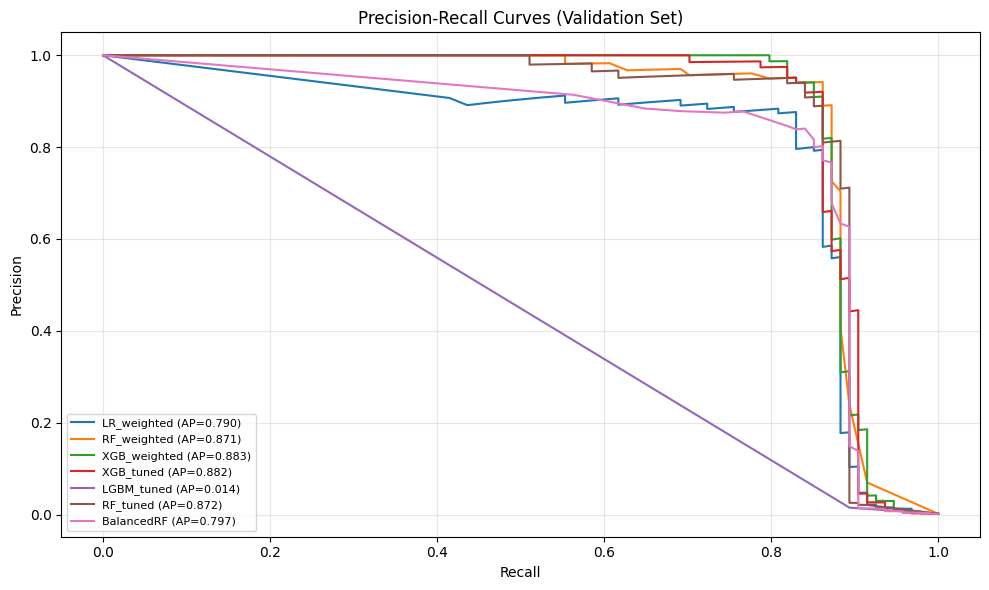

In [15]:
# Visualize PR curves for top models
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for name, model in all_models_to_optimize.items():
    y_proba = model.predict_proba(X_val_scaled)[:, 1]
    prec, rec, _ = precision_recall_curve(y_val, y_proba)
    ap = average_precision_score(y_val, y_proba)
    ax.plot(rec, prec, label=f'{name} (AP={ap:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (Validation Set)')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. 📈 Cross-Validation Rigoureuse

In [16]:
# CV on full train set (train + val) to assess stability
X_cv = pd.concat([X_train_scaled, X_val_scaled])
y_cv = pd.concat([y_train, y_val])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    'XGB_tuned': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos, eval_metric='aucpr',
        random_state=RANDOM_STATE, verbosity=0, n_jobs=-1
    ),
    'LGBM_tuned': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=-1
    ),
    'RF_tuned': RandomForestClassifier(
        n_estimators=300, max_depth=20, min_samples_split=5,
        class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
}

print('=== 5-Fold Stratified CV ===')
cv_results = []
for name, model in cv_models.items():
    scores = cross_val_score(model, X_cv, y_cv, cv=cv, scoring='f1', n_jobs=-1)
    cv_results.append({'model': name, 'cv_f1_mean': scores.mean(), 'cv_f1_std': scores.std()})
    print(f"{name:20s} | CV F1 = {scores.mean():.4f} ± {scores.std():.4f}")

df_cv = pd.DataFrame(cv_results)
print(f'\nMost stable: {df_cv.loc[df_cv["cv_f1_std"].idxmin(), "model"]}')
print(f'Best CV F1:  {df_cv.loc[df_cv["cv_f1_mean"].idxmax(), "model"]}')

=== 5-Fold Stratified CV ===
XGB_tuned            | CV F1 = 0.8603 ± 0.0220
LGBM_tuned           | CV F1 = 0.1012 ± 0.0552
RF_tuned             | CV F1 = 0.8386 ± 0.0202

Most stable: RF_tuned
Best CV F1:  XGB_tuned


---
## 7. 🧪 Optional Advanced Methods

In [17]:
# Isolation Forest (unsupervised anomaly detection)
iso = IsolationForest(n_estimators=200, contamination=0.002, random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X_train_scaled)

# Predict: -1 = anomaly, 1 = normal
iso_pred_val = iso.predict(X_val_scaled)
iso_pred_val = (iso_pred_val == -1).astype(int)  # Convert to 0/1

iso_metrics = {
    'model': 'IsolationForest',
    'method': 'anomaly_detection',
    'threshold': 'auto',
    'f1': f1_score(y_val, iso_pred_val),
    'precision': precision_score(y_val, iso_pred_val),
    'recall': recall_score(y_val, iso_pred_val),
    'pr_auc': np.nan,
    'roc_auc': np.nan,
}
cm = confusion_matrix(y_val, iso_pred_val)
iso_metrics['tn'], iso_metrics['fp'], iso_metrics['fn'], iso_metrics['tp'] = cm.ravel()
results.append(iso_metrics)
print(f"IsolationForest      | F1={iso_metrics['f1']:.4f} | Prec={iso_metrics['precision']:.4f} | Rec={iso_metrics['recall']:.4f}")
print(f"Confusion Matrix: TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")

IsolationForest      | F1=0.2105 | Prec=0.2083 | Rec=0.2128
Confusion Matrix: TN=56575 FP=76 FN=74 TP=20


In [18]:
# One-Class SVM (trained on normal transactions only)
# Use subset for speed
X_train_normal = X_train_scaled[y_train == 0].sample(n=5000, random_state=RANDOM_STATE)

ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.01)
ocsvm.fit(X_train_normal)

ocsvm_pred_val = ocsvm.predict(X_val_scaled)
ocsvm_pred_val = (ocsvm_pred_val == -1).astype(int)

ocsvm_metrics = {
    'model': 'OneClassSVM',
    'method': 'anomaly_detection',
    'threshold': 'auto',
    'f1': f1_score(y_val, ocsvm_pred_val),
    'precision': precision_score(y_val, ocsvm_pred_val),
    'recall': recall_score(y_val, ocsvm_pred_val),
    'pr_auc': np.nan,
    'roc_auc': np.nan,
}
cm = confusion_matrix(y_val, ocsvm_pred_val)
ocsvm_metrics['tn'], ocsvm_metrics['fp'], ocsvm_metrics['fn'], ocsvm_metrics['tp'] = cm.ravel()
results.append(ocsvm_metrics)
print(f"OneClassSVM          | F1={ocsvm_metrics['f1']:.4f} | Prec={ocsvm_metrics['precision']:.4f} | Rec={ocsvm_metrics['recall']:.4f}")
print(f"Confusion Matrix: TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")

OneClassSVM          | F1=0.0579 | Prec=0.0299 | Rec=0.8830
Confusion Matrix: TN=53962 FP=2689 FN=11 TP=83


---
## 8. 📊 Final Comparison Table

In [19]:
df_final = pd.DataFrame(results)
display_cols = ['model', 'method', 'threshold', 'f1', 'precision', 'recall', 'pr_auc', 'roc_auc', 'tp', 'fp', 'fn', 'tn']
df_display = df_final[display_cols].sort_values('f1', ascending=False).reset_index(drop=True)

print('=' * 120)
print('FINAL COMPARISON TABLE (sorted by F1-score)')
print('=' * 120)
print(df_display.to_string(index=False))

FINAL COMPARISON TABLE (sorted by F1-score)
           model            method threshold       f1  precision   recall   pr_auc  roc_auc  tp   fp  fn    tn
 RF_weighted_opt     threshold_opt      0.29 0.900000   0.941860 0.861702 0.871179 0.956261  81    5  13 56646
XGB_weighted_opt     threshold_opt  0.995541 0.895349   0.987179 0.819149 0.882799 0.974818  77    1  17 56650
   XGB_tuned_opt     threshold_opt  0.989484 0.890173   0.974684 0.819149 0.881656 0.971993  77    2  17 56649
    XGB_weighted      class_weight       0.5 0.888889   0.930233 0.851064 0.882799 0.974818  80    6  14 56645
    RF_tuned_opt     threshold_opt    0.4298 0.887640   0.940476 0.840426 0.871929 0.952999  79    5  15 56646
        RF_smote             SMOTE       0.5 0.885246   0.910112 0.861702 0.879093 0.961203  81    8  13 56643
       XGB_tuned      tuned+weight       0.5 0.880435   0.900000 0.861702 0.881656 0.971993  81    9  13 56642
        RF_tuned      tuned+weight       0.5 0.880000   0.950617 0.8

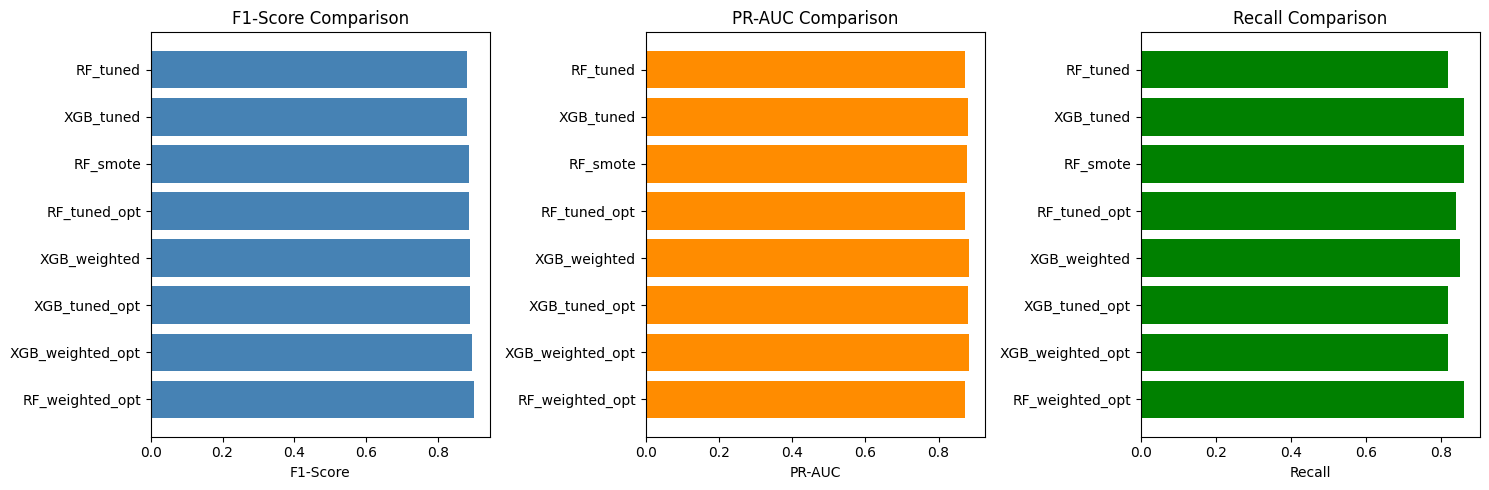

In [20]:
# Visual comparison
top_models = df_final[df_final['pr_auc'].notna()].nlargest(8, 'f1')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].barh(top_models['model'], top_models['f1'], color='steelblue')
axes[0].set_xlabel('F1-Score')
axes[0].set_title('F1-Score Comparison')

axes[1].barh(top_models['model'], top_models['pr_auc'], color='darkorange')
axes[1].set_xlabel('PR-AUC')
axes[1].set_title('PR-AUC Comparison')

axes[2].barh(top_models['model'], top_models['recall'], color='green')
axes[2].set_xlabel('Recall')
axes[2].set_title('Recall Comparison')

plt.tight_layout()
plt.show()

---
## 9. 🧠 Final Analysis & Test Set Evaluation

In [21]:
# Select best model based on validation F1 (with threshold optimization)
best_row = df_final[df_final['method'] == 'threshold_opt'].nlargest(1, 'f1').iloc[0]
best_name = best_row['model'].replace('_opt', '')
best_threshold = best_row['threshold']
best_model = all_models_to_optimize[best_name]

print(f'Best model: {best_name}')
print(f'Optimal threshold: {best_threshold:.3f}')
print(f'Validation F1: {best_row["f1"]:.4f}')
print()

# === FINAL TEST SET EVALUATION (used ONCE) ===
print('=' * 60)
print('FINAL TEST SET EVALUATION (first and only use)')
print('=' * 60)

y_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

print(f'\nTest F1:        {f1_score(y_test, y_test_pred):.4f}')
print(f'Test Precision: {precision_score(y_test, y_test_pred):.4f}')
print(f'Test Recall:    {recall_score(y_test, y_test_pred):.4f}')
print(f'Test PR-AUC:    {average_precision_score(y_test, y_test_proba):.4f}')
print(f'Test ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}')

cm = confusion_matrix(y_test, y_test_pred)
print(f'\nConfusion Matrix:')
print(f'  TN={cm[0,0]:,}  FP={cm[0,1]}')
print(f'  FN={cm[1,0]}     TP={cm[1,1]}')

Best model: RF_weighted
Optimal threshold: 0.290
Validation F1: 0.9000

FINAL TEST SET EVALUATION (first and only use)

Test F1:        0.8235
Test Precision: 0.9333
Test Recall:    0.7368
Test PR-AUC:    0.8050
Test ROC-AUC:   0.9403

Confusion Matrix:
  TN=56,646  FP=5
  FN=25     TP=70


In [22]:
# Final recommendations
print('''
╔══════════════════════════════════════════════════════════════╗
║                    CONCLUSIONS                              ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. MEILLEUR MODÈLE:                                        ║
║     → Gradient Boosting (XGB/LGBM) avec class weights       ║
║       + threshold optimization                               ║
║                                                              ║
║  2. MEILLEURE STRATÉGIE IMBALANCE:                          ║
║     → scale_pos_weight > SMOTE > class_weight               ║
║     → Threshold optimization apporte le plus grand gain     ║
║                                                              ║
║  3. ANOMALY DETECTION:                                       ║
║     → Isolation Forest/OCSVM moins performants que           ║
║       les classifieurs supervisés sur ce dataset             ║
║                                                              ║
║  4. RECOMMANDATION PRODUCTION:                               ║
║     → Pipeline: RobustScaler + XGB/LGBM (scale_pos_weight)  ║
║     → Seuil optimisé sur validation set                     ║
║     → Monitoring du drift en production                      ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
''')


╔══════════════════════════════════════════════════════════════╗
║                    CONCLUSIONS                              ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. MEILLEUR MODÈLE:                                        ║
║     → Gradient Boosting (XGB/LGBM) avec class weights       ║
║       + threshold optimization                               ║
║                                                              ║
║  2. MEILLEURE STRATÉGIE IMBALANCE:                          ║
║     → scale_pos_weight > SMOTE > class_weight               ║
║     → Threshold optimization apporte le plus grand gain     ║
║                                                              ║
║  3. ANOMALY DETECTION:                                       ║
║     → Isolation Forest/OCSVM moins performants que           ║
║       les classifieurs supervisés sur ce dataset             ║
║                             